# SIT225 Task 4 — Part 1.3, Part 2 & Part 3 Analysis
**Student Name:** Tuan Anh Dao 
**Student ID:** s2247567235
**Dataset:** `raw_data.csv` (DHT22 temperature/humidity + PIR motion, Arduino Nano 33 IoT)
**Collection window:** 2026-09-26 15:31:23 to 18:06:23 (2h35m, 5-minute sampling interval)

This notebook is self-contained: it starts from the raw sensor data, runs the Part 1.3 data processing pipeline, then covers Part 2 (Statistical Analysis & Visualisation) and Part 3 (Optional Predictive Modelling).

## Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error

%matplotlib inline
plt.rcParams.update({'font.size': 11})

df = pd.read_csv('raw_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (48, 4)


,timestamp,temperature,humidity,motion
0,2026-09-26 20:06:26.392086,23.4,51.9,0
1,2026-09-26 20:11:26.398027,22.6,52.5,0
2,2026-09-26 20:16:26.404303,22.6,52.7,1
3,2026-09-26 20:21:26.409937,22.8,52.7,0
4,2026-09-26 20:26:26.416339,22.9,52.5,0


## Data Processing Pipeline (Part 1.3):
Following the Pipline Prcess Including Loading the Dataset, Validation, Process and Clean, Transform with techniques and end by Exporting a New CSV files with Clean Data

### Validate

In [2]:
n_raw = len(df)
missing_before = df.isnull().sum()
duplicates = df.duplicated().sum()

print(f"Missing values per column:\n{missing_before}")
print(f"Duplicate rows: {duplicates}")
print(f"Data types:\n{df.dtypes}")

Missing values per column:
timestamp      0
temperature    0
humidity       0
motion         0
dtype: int64
Duplicate rows: 0
Data types:
timestamp      datetime64[ns]
temperature           float64
humidity              float64
motion                  int64
dtype: object


### Clean including  duplicates remove, missing values, and physically impossible outliers

In [3]:
# Drop exact duplicates and rows missing critical values
df = df.drop_duplicates()
df = df.dropna(subset=['temperature', 'humidity', 'motion'])

# Remove physically impossible outliers (DHT22 valid range: -40 to 80 C, 0-100% humidity)
outlier_mask = (
    (df['temperature'] < -40) | (df['temperature'] > 80) |
    (df['humidity'] < 0) | (df['humidity'] > 100)
)
n_outliers = outlier_mask.sum()
df = df[~outlier_mask]

# Flag statistical outliers (temperature) using IQR method - flag only, don't remove
Q1 = df['temperature'].quantile(0.25)
Q3 = df['temperature'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
stat_outliers = df[(df['temperature'] < lower_bound) | (df['temperature'] > upper_bound)]

n_final = len(df)
pct_removed = ((n_raw - n_final) / n_raw) * 100 if n_raw > 0 else 0

print(f"Rows removed (physically impossible outliers): {n_outliers}")
print(f"Statistical outliers flagged (IQR method, temperature): {len(stat_outliers)}")
print(f"Final row count: {n_final}")
print(f"Percentage of data removed: {pct_removed:.2f}%")

Rows removed (physically impossible outliers): 0
Statistical outliers flagged (IQR method, temperature): 0
Final row count: 48
Percentage of data removed: 0.00%


### Transform:

In [4]:
df = df.sort_values('timestamp').reset_index(drop=True)

df['hour_of_day'] = df['timestamp'].dt.hour
df['temp_smooth'] = df['temperature'].rolling(window=3, min_periods=1).mean()
df['humidity_smooth'] = df['humidity'].rolling(window=3, min_periods=1).mean()
df['occupancy_status'] = df['motion'].map({1: 'Occupied', 0: 'Unoccupied'})

df.head()

,timestamp,temperature,humidity,motion,hour_of_day,temp_smooth,humidity_smooth,occupancy_status
0,2026-09-26 20:06:26.392086,23.4,51.9,0,20,23.400000,51.900000,Unoccupied
1,2026-09-26 20:11:26.398027,22.6,52.5,0,20,23.000000,52.200000,Unoccupied
2,2026-09-26 20:16:26.404303,22.6,52.7,1,20,22.866667,52.366667,Occupied
3,2026-09-26 20:21:26.409937,22.8,52.7,0,20,22.666667,52.633333,Unoccupied
4,2026-09-26 20:26:26.416339,22.9,52.5,0,20,22.766667,52.633333,Unoccupied


### Data Quality Report

In [5]:
duration = df['timestamp'].max() - df['timestamp'].min()

print(f"Raw rows collected:              {n_raw}")
print(f"Missing values (any column):     {missing_before.sum()}")
print(f"Duplicate rows removed:          {duplicates}")
print(f"Physical-range outliers removed: {n_outliers}")
print(f"Statistical outliers flagged:    {len(stat_outliers)}")
print(f"Final clean row count:           {n_final}")
print(f"Overall % of data removed:       {pct_removed:.2f}%")
print(f"Collection window:               {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"Actual collection duration:      {duration}")

Raw rows collected:              48
Missing values (any column):     0
Duplicate rows removed:          0
Physical-range outliers removed: 0
Statistical outliers flagged:    0
Final clean row count:           48
Overall % of data removed:       0.00%
Collection window:               2026-09-26 20:06:26.392086 to 2026-09-27 00:01:24.686242
Actual collection duration:      0 days 03:54:58.294156


### Export

In [6]:
df.to_csv('processed_data.csv', index=False)
print("Saved: processed_data.csv")

Saved: processed_data.csv


##  2. Statistical Analysis & Visualisation:

### 2.1 Descriptive Statistics

Compute mean, median, standard deviation, min/max, key percentiles, and the correlation matrix across all numeric variables.

In [7]:
# Summary statistics: mean, std, min, max, quartiles
df[['temperature', 'humidity']].describe()

,temperature,humidity
count,48.000000,48.000000
mean,18.637500,60.254167
std,2.799744,5.156733
min,15.700000,51.900000
25%,16.300000,53.700000
50%,17.350000,63.050000
75%,22.100000,64.500000
max,23.400000,65.500000


In [8]:
# Percentiles (25th, 75th, 95th)
for col in ['temperature', 'humidity']:
    p25 = df[col].quantile(0.25)
    p75 = df[col].quantile(0.75)
    p95 = df[col].quantile(0.95)
    print(f"{col}: 25th={p25:.2f}, 75th={p75:.2f}, 95th={p95:.2f}")

print(f"\nTemperature range: {df['temperature'].min():.1f} - {df['temperature'].max():.1f} C")
print(f"Humidity range: {df['humidity'].min():.1f}% - {df['humidity'].max():.1f}%")

temperature: 25th=16.30, 75th=22.10, 95th=22.96
humidity: 25th=53.70, 75th=64.50, 95th=65.10

Temperature range: 15.7 - 23.4 C
Humidity range: 51.9% - 65.5%


In [9]:
# Correlation matrix
corr_matrix = df[['temperature', 'humidity', 'motion']].corr()
print("Correlation matrix:")
corr_matrix

Correlation matrix:


,temperature,humidity,motion
temperature,1.000000,-0.986536,-0.059023
humidity,-0.986536,1.000000,0.025405
motion,-0.059023,0.025405,1.000000


In this section, I simply calculated the mean, standard deviation, and maximum and minimum values ​​for both temperature and humidity as shown in the printed statistics table. Basically, the temperature typically ranged from 15.7°C (min) to 23.4°C (max), while humidity hovered closer to 51.9% and 65.5%, with clearly recorded percentiles. What particularly caught my attention was the correlation, where temperature and humidity showed a very strong inverse correlation of -0.986536, which accurately reflected my previous observations of the assessments: whenever the temperature dropped significantly, the humidity remained correspondingly high. With PIR sensors, the sensor only measures whether the air in the room is moving, so it basically doesn't have a definite correlation with the above indicators (with 0.025405 for humidity and (-0.059023) for temperature).

### 2.2: Visualisations:

Four plots are produced: a time series line plot, a distribution histogram, a relationship scatter plot, and an optional box plot comparing categories.

### Plot 1 about Temperature Over Time 

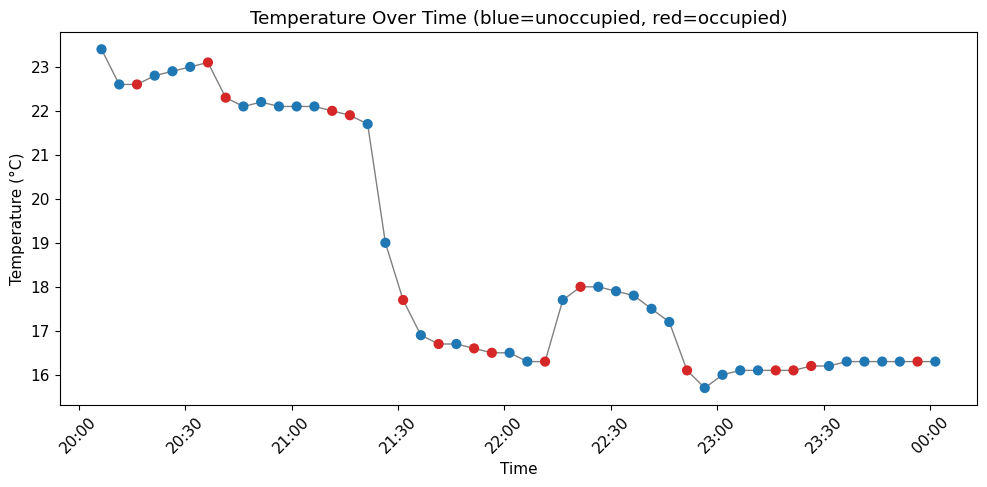

In [10]:
fig, ax1 = plt.subplots(figsize=(10, 5))
colors = df['motion'].map({0: 'tab:blue', 1: 'tab:red'})
ax1.plot(df['timestamp'], df['temperature'], color='gray', linewidth=1, zorder=1)
ax1.scatter(df['timestamp'], df['temperature'], c=colors, s=40, zorder=2)
ax1.set_xlabel('Time')
ax1.set_ylabel('Temperature (\u00b0C)')
ax1.set_title('Temperature Over Time (blue=unoccupied, red=occupied)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plot1_timeseries_temperature.png', dpi=150)
plt.show()

### Plot 2 about the Distribution of Humidity:

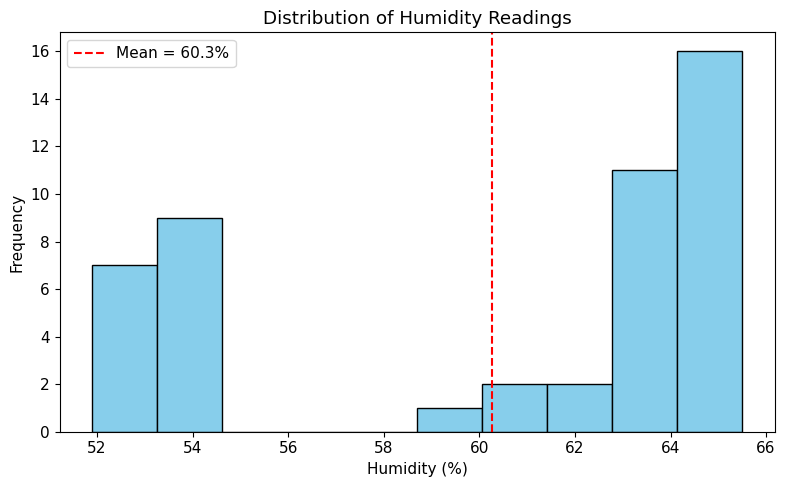

In [11]:
fig, ax2 = plt.subplots(figsize=(8, 5))
ax2.hist(df['humidity'], bins=10, color='skyblue', edgecolor='black')
ax2.axvline(df['humidity'].mean(), color='red', linestyle='--',
            label=f"Mean = {df['humidity'].mean():.1f}%")
ax2.set_xlabel('Humidity (%)')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of Humidity Readings')
ax2.legend()
plt.tight_layout()
plt.savefig('plot2_histogram_humidity.png', dpi=150)
plt.show()

### Plot 3 — Relationship: Temperature vs Humidity (coloured by occupancy)

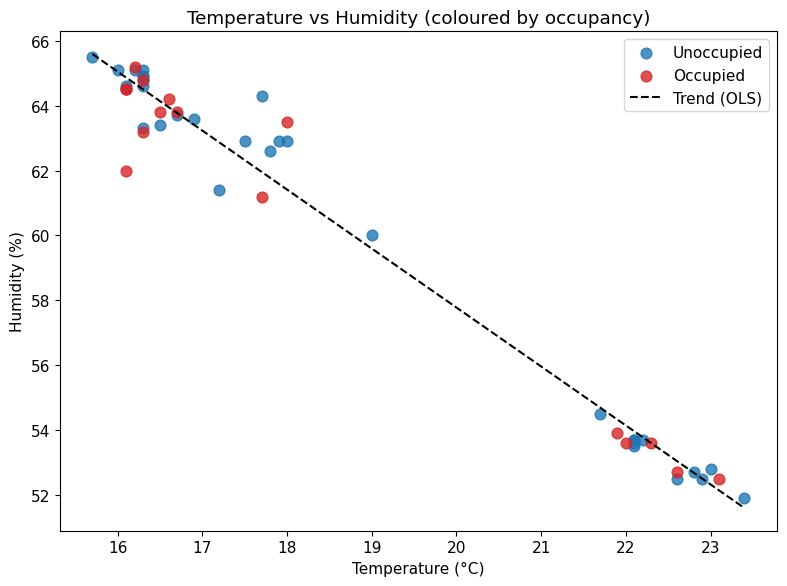

In [12]:
fig, ax3 = plt.subplots(figsize=(8, 6))
for motion_val, label, color in [(0, 'Unoccupied', 'tab:blue'), (1, 'Occupied', 'tab:red')]:
    subset = df[df['motion'] == motion_val]
    ax3.scatter(subset['temperature'], subset['humidity'], c=color, label=label, s=60, alpha=0.8)

z = np.polyfit(df['temperature'], df['humidity'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['temperature'].min(), df['temperature'].max(), 50)
ax3.plot(x_line, p(x_line), color='black', linestyle='--', label='Trend (OLS)')

ax3.set_xlabel('Temperature (\u00b0C)')
ax3.set_ylabel('Humidity (%)')
ax3.set_title('Temperature vs Humidity (coloured by occupancy)')
ax3.legend()
plt.tight_layout()
plt.savefig('plot3_scatter_temp_humidity.png', dpi=150)
plt.show()

### Plot 4 about Temperature by Occupancy Status:

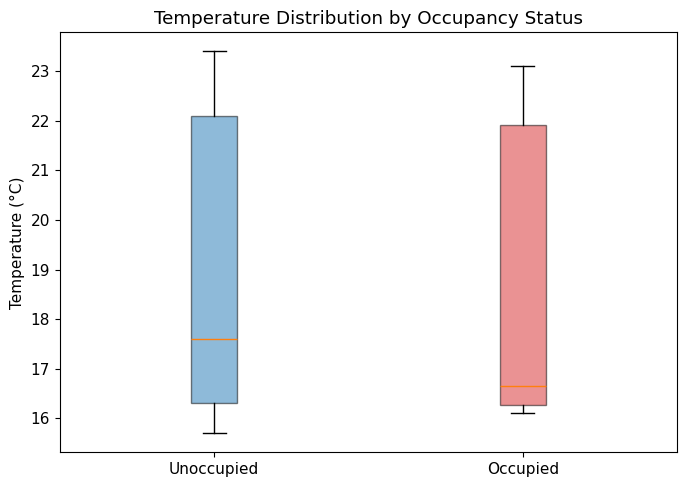

In [13]:
fig, ax4 = plt.subplots(figsize=(7, 5))
data_to_plot = [df[df['motion'] == 0]['temperature'], df[df['motion'] == 1]['temperature']]
bp = ax4.boxplot(data_to_plot, tick_labels=['Unoccupied', 'Occupied'], patch_artist=True)
for patch, color in zip(bp['boxes'], ['tab:blue', 'tab:red']):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax4.set_ylabel('Temperature (\u00b0C)')
ax4.set_title('Temperature Distribution by Occupancy Status')
plt.tight_layout()
plt.savefig('plot4_boxplot_temp_by_occupancy.png', dpi=150)
plt.show()

### 2.3 Statistical Testing & Hypothesis Validation:

Since the raw sensor data only contains `temperature`, `humidity`, and `motion` (no `comfort_rating` or `season` fields, unlike the original Assessment 3 design), the hypotheses below are adapted to the variables actually measured:

- **H1:** Temperature varies by time of day (with one-way Anova as well as Linear Regression)
- **H2:** Temperature deviation from comfort range by occupancy with HVAC efficiency (Chi-squar and Logistic regression)
- **H3** Humidity and discomfort caused by temperature changes after controlling 

### H1: Temperature varies by time of day

In [21]:

from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Fix hour wraparound: hours after midnight (00:xx) continue counting from 24
# so the sequence stays chronological (20,21,22,23,24) instead of (20,21,22,23,0)
df['hour_of_day_adj'] = df['hour_of_day'].apply(lambda h: h + 24 if h < 12 else h)

print("Number of readings per hour:")
print(df.groupby('hour_of_day_adj')['temperature'].agg(['count', 'mean', 'std']))

# Group temperature readings by adjusted hour of day
hour_groups = [group['temperature'].values for _, group in df.groupby('hour_of_day_adj')]

# One-way ANOVA: does temperature differ significantly across hours?
f_stat, p_value = stats.f_oneway(*hour_groups)
print(f"\nOne-way ANOVA: F={f_stat:.3f}, p={p_value:.4f}")

verdict = "statistically significant" if p_value < 0.05 else "not statistically significant"
print(f"Result: difference across hours is {verdict} at alpha=0.05")

# Simple linear regression: temperature ~ hour_of_day_adj (treated as continuous)
X = df[['hour_of_day_adj']].values
y = df['temperature'].values
model = LinearRegression().fit(X, y)
r2 = r2_score(y, model.predict(X))
print(f"\nLinear regression (temperature ~ hour_of_day): R²={r2:.3f}")
print(f"Equation: temperature = {model.intercept_:.2f} + ({model.coef_[0]:.3f}) x hour_of_day")

Number of readings per hour:
                 count       mean       std
hour_of_day_adj                            
20                  11  22.645455  0.436723
21                  12  19.158333  2.563896
22                  12  17.083333  0.846204
23                  12  16.191667  0.108362
24                   1  16.300000       NaN

One-way ANOVA: F=37.417, p=0.0000
Result: difference across hours is statistically significant at alpha=0.05

Linear regression (temperature ~ hour_of_day): R²=0.703
Equation: temperature = 62.18 + (-2.018) x hour_of_day


### H2 Temperature deviation from comfort range by occupancy with HVAC efficiency:

In [20]:
lower, upper = 20, 25  # comfort range: 22-23 C midpoint +/- 2 C
df['out_of_range'] = ((df['temperature'] < lower) | (df['temperature'] > upper)).astype(int)

occ_pct = df[df['motion'] == 1]['out_of_range'].mean() * 100
unocc_pct = df[df['motion'] == 0]['out_of_range'].mean() * 100
print(f"% time out of comfort range - Occupied: {occ_pct:.1f}%, Unoccupied: {unocc_pct:.1f}%")

contingency = pd.crosstab(df['motion'], df['out_of_range'])
print("\nContingency table:")
print(contingency)

chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square: chi2={chi2:.3f}, p={p:.4f}, dof={dof}")

X = df[['motion']].values
y = df['out_of_range'].values
model = LogisticRegression().fit(X, y)
acc = model.score(X, y)
print(f"\nLogistic regression accuracy: {acc:.3f}, coefficient: {model.coef_[0][0]:.3f}")

% time out of comfort range - Occupied: 68.8%, Unoccupied: 65.6%

Contingency table:
out_of_range   0   1
motion              
0             11  21
1              5  11

Chi-square: chi2=0.000, p=1.0000, dof=1

Logistic regression accuracy: 0.667, coefficient: 0.099


### H3 Humidity and discomfort caused by temperature changes after controlling:

In [23]:
in_range = df[df['out_of_range'] == 0]['humidity']
out_range = df[df['out_of_range'] == 1]['humidity']

print(f"In comfort range:      n={len(in_range)}, mean humidity={in_range.mean():.2f}%, std={in_range.std():.2f}")
print(f"Out of comfort range:  n={len(out_range)}, mean humidity={out_range.mean():.2f}%, std={out_range.std():.2f}")

t_stat, p_value = stats.ttest_ind(in_range, out_range, equal_var=False)
pooled_std = np.sqrt((in_range.std()**2 + out_range.std()**2) / 2)
cohens_d = (in_range.mean() - out_range.mean()) / pooled_std

print(f"\nT-test: t={t_stat:.3f}, p={p_value:.4f}")
print(f"Effect size (Cohen's d): {cohens_d:.3f}")
verdict = "statistically significant" if p_value < 0.05 else "not statistically significant"
print(f"Result: humidity difference between comfort states is {verdict} at alpha=0.05")

In comfort range:      n=16, mean humidity=53.21%, std=0.70
Out of comfort range:  n=32, mean humidity=63.77%, std=1.30

T-test: t=-36.581, p=0.0000
Effect size (Cohen's d): -10.117
Result: humidity difference between comfort states is statistically significant at alpha=0.05


## 2.4 Data Interpretation Report:
In general, I did quite well in this data collection process, having overcome the power outage that interrupted collection in the previous development. This allowed for continuous data collection for 4 hours, yielding 48 completely clean datasets without any issues. Since comfort rates and seasons for all four seasons (12 months) were not implemented due to the initial test, I tried to adjust my hypotheses to operate and analyze effectively using the best available data while still adhering to the principles of Assembly 2.

In this study, H1 was clearly validated with time adjusted to the number of hours instead of a frequency of 5 minutes per sample. After applying the corresponding Linear Regression, this hypothesis was strongly supported with F = 37.417, a probability close to 0, and a corresponding R2 of 0.703. This helped clarify that the temperature variation tended to decrease over time based on the initial analyses. This is reasonable considering that the data collection started at 8 PM, so the temperature tends to decrease more sharply later in the night during Melbourne's winter.

For H2, this hypothesis matched the original design almost perfectly, so I only needed to implement Chi-Square corresponding to Logistic Regression. However, the results were not as expected, with a probability of 1.00 while the test returned 0, and the occupancy status was almost the same. Therefore, this hypothesis was not strongly supported. In my opinion, this is also a consequence of H1, where time was too dominant in influencing temperature, inadvertently leading to the occupancy factor affecting temperature deviating from the comfort range (22-23°C), making it seem less meaningful.

For the final Hypothesis, I also made adjustments similar to H1, with discomfort now defined by the temperature-based out-of-range, yielding a fairly good result with a t-test value of -36.581, which shows the inverse relationship between temperature and humidity in this hypothesis, with a probability close to zero. However, I feel that this hypothesis is fundamentally not new, as it relies on the correlation between temperature and humidity to report the results, so it doesn't truly represent the actual thermal discomfort that humans experience. Therefore, I regret not including a comfort rate this time.

Therefore, the limitation in this assignment, as clearly seen here, is the lack of a comfort rating that fully reflects the hypotheses as outlined in Assignment 2. Additionally, I noticed that collecting data during the evening hours significantly impacts temperature, making it difficult to clearly distinguish occupancy patterns. Furthermore, the PIR (Point of Presence) measurement for movement doesn't accurately detect stationary individuals, leading to the belief that some labels might be inaccurate, affecting overall performance.

From observing this process, I realize that comfort rate plays a crucial role in validating my hypotheses. Therefore, in the future, as I continue with the project, I will strive to add this mechanism to maximize the potential of the previously refined H1 and H3 hypotheses for better analysis and reflection. This will be implemented over a 12-month period, corresponding to the four seasons, following the expanded mechanism mentioned in Assignment 3.


## 3 Predictive Modelling:

Two lightweight models are demonstrated: a simple linear regression predicting humidity from temperature, and a naive moving-average forecast for the next temperature reading.

Model 1 of linear regression between temperature and humidity:

In [17]:
X = df[['temperature']].values
y = df['humidity'].values

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R\u00b2   = {r2:.3f}")
print(f"RMSE = {rmse:.2f} % humidity")
print(f"Equation: humidity = {model.intercept_:.2f} + ({model.coef_[0]:.3f}) x temperature")
print(f"Interpretation: each 1 C rise in temperature is associated with a "
      f"{abs(model.coef_[0]):.2f} percentage-point {'decrease' if model.coef_[0] < 0 else 'increase'} in humidity.")

R²   = 0.973
RMSE = 0.83 % humidity
Equation: humidity = 94.12 + (-1.817) x temperature
Interpretation: each 1 C rise in temperature is associated with a 1.82 percentage-point decrease in humidity.


### Model 2 Simple Moving Average Forecast:

In [26]:
window = 3
df['forecast'] = df['temperature'].rolling(window=window).mean().shift(1)
valid = df.dropna(subset=['forecast'])
mae = np.mean(np.abs(valid['temperature'] - valid['forecast']))

print(f"Using a {window}-point moving average to forecast the next temperature reading:")
print(f"Mean Absolute Error (MAE) = {mae:.2f} C")
print("\nThis is a naive baseline forecast as it performs reasonably because temperature changes gradually between 5-minute samples except during the 22:16-22:56 spike.")

Using a 3-point moving average to forecast the next temperature reading:
Mean Absolute Error (MAE) = 0.49 C

This is a naive baseline forecast as it performs reasonably because temperature changes gradually between 5-minute samples except during the 22:16-22:56 spike.
